In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    roc_auc_score, RocCurveDisplay, precision_score, recall_score, f1_score
)
import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.4f}".format)

# Load the two versions we prepared
X_train = pd.read_csv("../data/processed/X_train_binary.csv")
y_train = pd.read_csv("../data/processed/y_train_binary.csv").squeeze()
X_test  = pd.read_csv("../data/processed/X_test_binary.csv")
y_test  = pd.read_csv("../data/processed/y_test_binary.csv").squeeze()

X_train_smote = pd.read_csv("../data/processed/X_train_binary_smotenc.csv")
y_train_smote = pd.read_csv("../data/processed/y_train_binary_smotenc.csv").squeeze()

print("Original train :", X_train.shape, "→", y_train.value_counts(normalize=True).round(3).to_dict())
print("SMOTENC train  :", X_train_smote.shape, "→", y_train_smote.value_counts(normalize=True).round(3).to_dict())
print("Test set       :", X_test.shape)

Original train : (202944, 21) → {0: 0.842, 1: 0.158}
SMOTENC train  : (341924, 21) → {1: 0.5, 0: 0.5}
Test set       : (50736, 21)


In [3]:
# Model A: Original data + class_weight='balanced'  (Primary / Cleaner approach)
lr_balanced = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
lr_balanced.fit(X_train, y_train)

# Model B: SMOTENC data
lr_smote = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
lr_smote.fit(X_train_smote, y_train_smote)

print("Both models trained successfully.")

Both models trained successfully.



 LogReg + class_weight='balanced'
              precision    recall  f1-score   support

           0     0.9417    0.7249    0.8192     42741
           1     0.3408    0.7601    0.4706      7995

    accuracy                         0.7305     50736
   macro avg     0.6412    0.7425    0.6449     50736
weighted avg     0.8470    0.7305    0.7643     50736

ROC-AUC : 0.8176


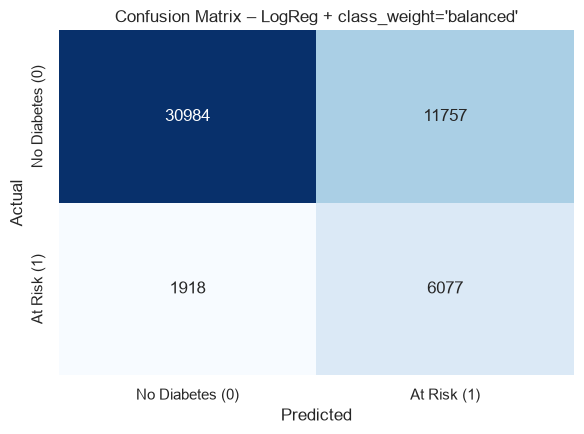


 LogReg + SMOTENC
              precision    recall  f1-score   support

           0     0.9372    0.7265    0.8185     42741
           1     0.3360    0.7398    0.4621      7995

    accuracy                         0.7286     50736
   macro avg     0.6366    0.7332    0.6403     50736
weighted avg     0.8425    0.7286    0.7624     50736

ROC-AUC : 0.8070


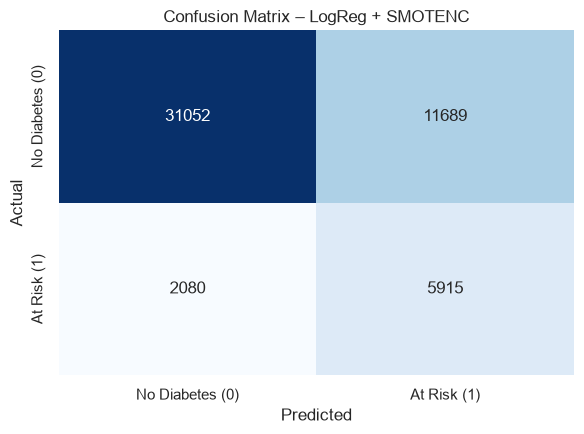

In [4]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n{'='*60}")
    print(f" {model_name}")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, digits=4))
    
    roc_auc = roc_auc_score(y_test, y_proba)
    print(f"ROC-AUC : {roc_auc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["No Diabetes (0)", "At Risk (1)"],
                yticklabels=["No Diabetes (0)", "At Risk (1)"])
    plt.title(f"Confusion Matrix – {model_name}", fontsize=12)
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

    return {
        "model_name": model_name,
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc,
        "y_proba": y_proba
    }

results_balanced = evaluate_model(lr_balanced, X_test, y_test, "LogReg + class_weight='balanced'")
results_smote    = evaluate_model(lr_smote, X_test, y_test, "LogReg + SMOTENC")

In [5]:
comparison = pd.DataFrame([
    {
        "Model": "class_weight='balanced'",
        "Precision": results_balanced["precision"],
        "Recall": results_balanced["recall"],
        "F1": results_balanced["f1"],
        "ROC-AUC": results_balanced["roc_auc"]
    },
    {
        "Model": "SMOTENC",
        "Precision": results_smote["precision"],
        "Recall": results_smote["recall"],
        "F1": results_smote["f1"],
        "ROC-AUC": results_smote["roc_auc"]
    }
])

print("\n=== Model Comparison ===")
print(comparison.round(4).to_string(index=False))


=== Model Comparison ===
                  Model  Precision  Recall     F1  ROC-AUC
class_weight='balanced'     0.3408  0.7601 0.4706   0.8176
                SMOTENC     0.3360  0.7398 0.4621   0.8070


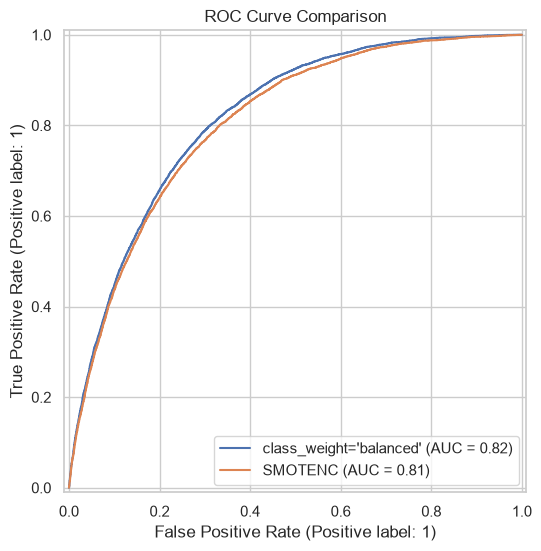

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    results_balanced["y_proba"],
    name="class_weight='balanced'",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test,
    results_smote["y_proba"],
    name="SMOTENC",
    ax=ax
)

plt.title("ROC Curve Comparison")
plt.show()

Top 12 features by absolute coefficient (class_weight model):

             Feature  Coefficient
           CholCheck       1.2063
              HighBP       0.6820
   HvyAlcoholConsump      -0.6129
            HighChol       0.5949
             GenHlth       0.5528
                 BMI       0.4883
                 Age       0.4639
                 Sex       0.2540
HeartDiseaseorAttack       0.2193
         NoDocbcCost       0.1002
              Stroke       0.0997
            DiffWalk       0.0752


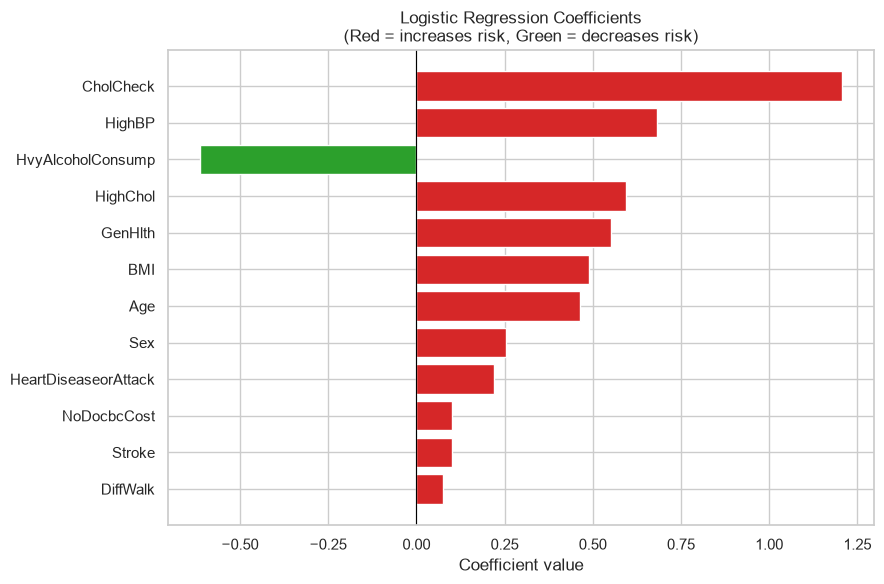

In [8]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr_balanced.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=False)

print("Top 12 features by absolute coefficient (class_weight model):\n")
print(coef_df.head(12).to_string(index=False))

# Visual
plt.figure(figsize=(9, 6))
top_coefs = coef_df.head(12)
colors = ["#d62728" if c > 0 else "#2ca02c" for c in top_coefs["Coefficient"]]
plt.barh(top_coefs["Feature"][::-1], top_coefs["Coefficient"][::-1], color=colors[::-1])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic Regression Coefficients\n(Red = increases risk, Green = decreases risk)")
plt.xlabel("Coefficient value")
plt.tight_layout()
plt.show()

### Day 4 Summary – Logistic Regression Baseline

**Which imbalance method performed better?**
- class_weight='balanced': Recall = ??? | ROC-AUC = ???
- SMOTENC: Recall = ??? | ROC-AUC = ???

**Winner:** ________________ (usually class_weight is cleaner and performs similarly or better)

**Do the coefficients make sense?**
- Positive coefficients expected: BMI, HighBP, HighChol, GenHlth, DiffWalk, Age, HeartDiseaseorAttack
- Negative coefficients expected: PhysActivity, Income, Education, Fruits/Veggies

**Key takeaway for next models:**
We will use the better of the two approaches (or both) when training Random Forest and XGBoost.